# 🧠 RNN Text Generation





| Symbol | Meaning |
|--------|---------|
| $x_t$ | Input at time step $t$ |
| $s_t$ | Hidden state (memory) at time $t$ |
| $y_t$ | Output at time step $t$ |
| $W$ | Weight matrix: input → hidden |
| $U$ | Weight matrix: hidden → hidden (recurrent) |
| $V$ | Weight matrix: hidden → output |
| $b_s$ | Bias for hidden state |
| $b_y$ | Bias for output |

### 🔁 RNN Forward Pass Equations

$$s_t = \tanh(W \cdot x_t + U \cdot s_{t-1} + b_s)$$

$$\hat{y}_t = \text{softmax}(V \cdot s_t + b_y)$$

### 📉 Loss Function (Cross-Entropy)

$$\mathcal{L} = -\sum_{t=1}^{T} \sum_{k=1}^{|V|} y_t^{(k)} \log \hat{y}_t^{(k)}$$

### 🔄 BPTT — Backpropagation Through Time

$$\frac{\partial \mathcal{L}}{\partial U} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}_t}{\partial U}$$

$$\frac{\partial \mathcal{L}_t}{\partial U} = \sum_{k=1}^{t} \frac{\partial \mathcal{L}_t}{\partial s_t} \cdot \left(\prod_{j=k+1}^{t} \frac{\partial s_j}{\partial s_{j-1}}\right) \cdot \frac{\partial s_k}{\partial U}$$

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

print("TensorFlow version:", tf.__version__)
print("NumPy version     :", np.__version__)

TensorFlow version: 2.19.0
NumPy version     : 2.0.2


## 📖 Step 2: Load Dataset — Shakespeare Corpus

We use the **Tiny Shakespeare** dataset — a collection of Shakespeare's works.  
This is the standard corpus used in character-level language modeling (Karpathy 2015).

In Prof. Khapra's notation:
- Each **character** is a token: $x_t \in \{0, 1\}^{|\mathcal{V}|}$ (one-hot)
- $|\mathcal{V}|$ = vocabulary size
- Corpus length = $N$ total characters

In [2]:
# Download Shakespeare dataset
path = keras.utils.get_file(
    "shakespeare.txt",
    "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt"
)

text = open(path, "rb").read().decode(encoding="utf-8")

print(f"Total characters  N = {len(text):,}")
print(f"\nFirst 300 characters:\n")
print(text[:300])

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total characters  N = 1,115,394

First 300 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## 🔤 Step 3: Build Vocabulary $\mathcal{V}$


$$\mathcal{V} = \text{set of all unique characters in corpus}$$
$$|\mathcal{V}| = \text{vocabulary size}$$

We create two mappings:
- `char2idx`: character → integer index
- `idx2char`: integer index → character

In [3]:
# Build vocabulary
vocab     = sorted(set(text))        # V = sorted unique chars
vocab_size = len(vocab)              # |V|

char2idx  = {c: i for i, c in enumerate(vocab)}
idx2char  = np.array(vocab)

print(f"Vocabulary size  |V| = {vocab_size}")
print(f"Characters: {vocab}")

print(char2idx)

print(idx2char[2])





Vocabulary size  |V| = 65
Characters: ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}
!


## 🔢 Step 4: Encode Text & Create Training Sequences

Convert each character $c$ to its index $i_c \in \{0, 1, \ldots, |\mathcal{V}|-1\}$

Training pairs following Khapra's **sequence-to-sequence** setup:
- **Input sequence:** $x_1, x_2, \ldots, x_T$  
- **Target sequence:** $x_2, x_3, \ldots, x_{T+1}$ *(shifted by 1)*

The model learns: **given $x_t$, predict $x_{t+1}$**

In [4]:
# Hyperparameters
T  = 100   # sequence length (time steps)
B  = 64    # batch size
d  = 256   # embedding dimension (d in Khapra's slides)

# Encode entire corpus
corpus_ids = np.array([char2idx[c] for c in text])

print(f"Corpus encoded: shape = {corpus_ids.shape}")
print(f"Sample ids: {corpus_ids[:20]}")
print(f"Sample chars: {''.join(idx2char[corpus_ids[:20]])}")

Corpus encoded: shape = (1115394,)
Sample ids: [18 47 56 57 58  1 15 47 58 47 64 43 52 10  0 14 43 44 53 56]
Sample chars: First Citizen:
Befor


In [5]:
# Build tf.data pipeline
# Input  : x_{1..T}
# Target : x_{2..T+1}  (shifted by 1 — next-char prediction)

dataset = (
    tf.data.Dataset
      .from_tensor_slices(corpus_ids)
      .batch(T + 1, drop_remainder=True)
      .map(lambda seq: (seq[:-1], seq[1:]))  # (x_t, x_{t+1})
      .shuffle(10_000)
      .batch(B, drop_remainder=True)
      .prefetch(tf.data.AUTOTUNE)
)

for x_batch, y_batch in dataset.take(1):
    print(f"Input  shape (B, T)     : {x_batch.shape}")
    print(f"Target shape (B, T)     : {y_batch.shape}")
    print(f"Sample input  chars: {''.join(idx2char[x_batch[0].numpy()[:30]])}")
    print(f"Sample target chars: {''.join(idx2char[y_batch[0].numpy()[:30]])}")

Input  shape (B, T)     : (64, 100)
Target shape (B, T)     : (64, 100)
Sample input  chars:  hath press'd
To lift shrewd s
Sample target chars: hath press'd
To lift shrewd st


## 🏗️ Step 5: Build the RNN Model



```
x_t  ──► Embedding ──► e_t ∈ R^d
                          │
s_{t-1} ─────────────────►│
                          ▼
             s_t = tanh(W·e_t + U·s_{t-1} + b_s)
                          │
                          ▼
             ŷ_t = softmax(V·s_t + b_y)
```

| Layer | Khapra Symbol | Keras Layer |
|-------|--------------|-------------|
| Embedding | $x_t \rightarrow e_t$ | `Embedding(|V|, d)` |
| Recurrent | $s_t = \tanh(W e_t + U s_{t-1} + b_s)$ | `SimpleRNN(H)` |
| Output | $\hat{y}_t = \text{softmax}(V s_t + b_y)$ | `Dense(|V|)` |

In [6]:
H = 1024   # hidden units (dimension of s_t)

def build_rnn_model(vocab_size, d, H, batch_size=None, stateful=False):
    """


        s_t = tanh(W·e_t + U·s_{t-1} + b_s)
        ŷ_t = softmax(V·s_t + b_y)

    Parameters
    ----------
    vocab_size : |V|  — vocabulary size
    d          : embedding dimension
    H          : hidden state dimension (size of s_t)
    batch_size : fixed batch size (required for stateful)
    stateful   : whether to carry hidden state across batches
    """
    # Input: x_t (integer token ids)
    x_t = keras.Input(
        shape=(T,),
        batch_size=batch_size,
        name="x_t"
    )

    # Embedding layer: x_t → e_t ∈ R^d
    e_t = layers.Embedding(
        input_dim=vocab_size,
        output_dim=d,
        name="embedding_W"
    )(x_t)   # shape: (B, T, d)

    # RNN layer: s_t = tanh(W·e_t + U·s_{t-1} + b_s)
    # Keras internally holds: W (kernel), U (recurrent_kernel), b_s (bias)
    s_t = layers.SimpleRNN(
        units=H,
        return_sequences=True,
        stateful=stateful,
        name="s_t_rnn"    # hidden state
    )(e_t)  # shape: (B, T, H)

    # Output layer: ŷ_t = V·s_t + b_y  (logits, softmax applied in loss)
    y_hat_t = layers.Dense(
        units=vocab_size,
        name="y_hat_logits"   # V matrix
    )(s_t)  # shape: (B, T, |V|)

    model = keras.Model(inputs=x_t, outputs=y_hat_t, name="RNN")
    return model


# Build training model
model = build_rnn_model(vocab_size, d, H)
model.summary()

Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ x_t (InputLayer)                │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_W (Embedding)         │ (None, 100, 256)       │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s_t_rnn (SimpleRNN)             │ (None, 100, 1024)      │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat_logits (Dense)            │ (None, 100, 65)        │        66,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,395,009 (5.32 MB)

 Trainable params: 1,395,009 (5.32 MB)

 Non-trainable params: 0 (0.00 B)

## 📉 Step 6: Loss Function & Optimizer

 **cross-entropy loss** for language modeling:

$$\mathcal{L} = -\frac{1}{T} \sum_{t=1}^{T} \log \hat{y}_t^{(x_{t+1})}$$

In Keras: `SparseCategoricalCrossentropy(from_logits=True)`  
*(targets are integer indices, not one-hot vectors)*

Optimizer: **Adam** (adaptive learning rate, commonly used in Khapra's assignments)

In [7]:
# Loss: L = -(1/T) Σ log ŷ_t[x_{t+1}]
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_fn
)

print("Model compiled ✓")
print(f"Loss function : SparseCategoricalCrossentropy (from_logits=True)")
print(f"Optimizer     : Adam (lr=0.001)")

Model compiled ✓
Loss function : SparseCategoricalCrossentropy (from_logits=True)
Optimizer     : Adam (lr=0.001)


## 🏋️ Step 7: Train the Model (BPTT)

Training uses **Backpropagation Through Time (BPTT)**

Gradient of loss w.r.t. recurrent weight $U$:

$$\frac{\partial \mathcal{L}}{\partial U} = \sum_{t=1}^{T} \sum_{k=1}^{t} \delta_t \cdot \left(\prod_{j=k+1}^{t} \text{diag}(1 - s_j^2) \cdot U\right) \cdot s_{k-1}^\top$$

> ⚠️ **Vanishing Gradient Problem**  
> The product $\prod_{j=k+1}^{t} \frac{\partial s_j}{\partial s_{j-1}}$ shrinks exponentially as $t - k$ increases.

In [9]:
import os
from tensorflow import keras

EPOCHS = 10

# Create checkpoint directory
os.makedirs("checkpoints", exist_ok=True)

# Correct filepath with required extension
checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath="checkpoints/rnn_epoch_{epoch:02d}.weights.h5",
    save_weights_only=True,
    save_best_only=False
)

print(f"Training for {EPOCHS} epochs...")
print(f"Each epoch trains on the full Shakespeare corpus.\n")

history = model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb]
)

Training for 10 epochs...
Each epoch trains on the full Shakespeare corpus.

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 350s 2s/step - loss: 1.3475
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 372s 2s/step - loss: 1.3264
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - loss: 1.3098
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - loss: 1.2933
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - loss: 1.2780
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - loss: 1.2621
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 344s 2s/step - loss: 1.2488
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - loss: 1.2358
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 351s 2s/step - loss: 1.2211
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - loss: 1.2095


## 📊 Step 8: Plot Training Loss

Visualize the **learning curve** — loss $\mathcal{L}$ vs. epoch.

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_444/768176929.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Cross-Entropy Loss $\mathcal{L}$", fontsize=12)


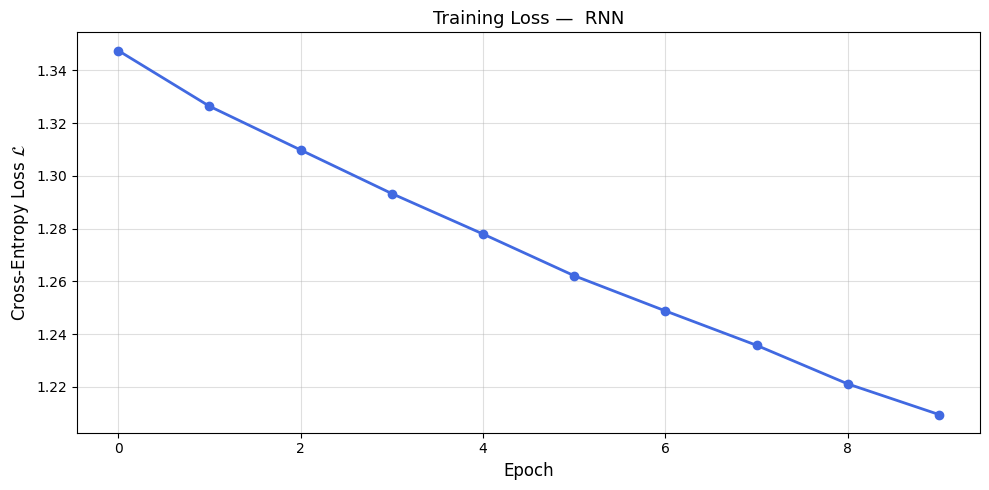

Final training loss: 1.2095


In [10]:
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], marker="o", color="royalblue", linewidth=2)
plt.title("Training Loss —  RNN",
          fontsize=13)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss $\mathcal{L}$", fontsize=12)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print(f"Final training loss: {history.history['loss'][-1]:.4f}")

## ✍️ Step 9: Text Generation with Temperature Sampling

Prof. Khapra's **inference / decoding** explanation:

At each step $t$, sample the next character from:

$$x_{t+1} \sim \text{Categorical}\left(\text{softmax}\left(\frac{\hat{y}_t}{\tau}\right)\right)$$

Where $\tau$ is the **temperature** parameter:

| Temperature $\tau$ | Effect |
|---------------------|--------|
| $\tau \to 0$ | Greedy decoding (argmax) |
| $\tau = 1.0$ | Standard sampling |
| $\tau > 1$ | More random / diverse output |

In [11]:
def generate_text(seed_string: str,
                  num_chars: int = 500,
                  temperature: float = 1.0) -> str:
    """
    Text generation using Mitesh Khapra's decoding formula:

        x_{t+1} ~ Categorical(softmax(ŷ_t / τ))

    Steps:
    1. Prime model with seed string (warm up hidden state s_t)
    2. At each step, compute ŷ_t = V·s_t + b_y
    3. Scale logits by temperature τ
    4. Sample next character from softmax distribution

    Parameters
    ----------
    seed_string : initial prompt to prime the RNN
    num_chars   : number of characters to generate
    temperature : τ — controls diversity of output
    """
    # Build single-step stateful model (B=1)
    gen_model = build_rnn_model(vocab_size, d, H, batch_size=1, stateful=True)
    gen_model.set_weights(model.get_weights())

    # Prime model: feed seed chars, update s_t
    for char in seed_string[:-1]:
        x_t = np.array([[char2idx[char]]])   # shape: (1, 1)
        gen_model(x_t)                        # advance s_t

    generated = list(seed_string)
    next_char  = seed_string[-1]

    for _ in range(num_chars):
        # Forward pass: x_t → s_t → ŷ_t
        x_t    = np.array([[char2idx[next_char]]])   # (1, 1)
        logits = gen_model(x_t)                      # (1, 1, |V|)

        # Temperature scaling: ŷ_t / τ
        logits = logits[0, 0].numpy() / temperature

        # Softmax: p_t = softmax(ŷ_t / τ)
        exp_logits  = np.exp(logits - np.max(logits))
        p_t         = exp_logits / exp_logits.sum()

        # Sample: x_{t+1} ~ Categorical(p_t)
        idx       = np.random.choice(vocab_size, p=p_t)
        next_char = idx2char[idx]
        generated.append(next_char)

    return "".join(generated)

print("Generator function defined ✓")

Generator function defined ✓


In [12]:
seed = "ROMEO: "

print("=" * 60)
print("   TEXT GENERATION DEMO")
print("=" * 60)

for tau in [0.2, 0.7, 1.0, 1.5]:
    print(f"\n── Temperature τ = {tau} {'(greedy)' if tau < 0.3 else '(random)' if tau > 1.2 else '(balanced)'} ──")
    print(generate_text(seed, num_chars=250, temperature=tau))
    print()

   TEXT GENERATION DEMO

── Temperature τ = 0.2 (greedy) ──
ROMEO: No, not the beauty to my boots, that you shall be so far for the world.

First Senator:
Now, by my father with the world to make me with the world with the wisest news are made the better for the world with me to make me but that you make me with the


── Temperature τ = 0.7 (balanced) ──
ROMEO: Marcius,
Make his love-stock--that was more hath and fight a little grace blow with me, and have been committed with him by my distress of the streets of my speeches
With the boys for your wives me with him, that we wind me for the town of those
That


── Temperature τ = 1.0 (balanced) ──
ROMEO: Verow myself a the grain?
Of my lordstally: unprtation should fall'd a temper'd.

MENENIUS:
Then let us be remembrance by a minister's tumb?

HASTINGS:
Is your mother was full avoided by mine.

GAULINA:
Who told me 'twill.

ESCALUS:
These griest rabe


── Temperature τ = 1.5 (random) ──
ROMEO: O, good, biow, Signob!--
Sandlest estitle-te

## ⚠️ Step 10: Vanishing Gradient Analysis



The gradient of $\mathcal{L}$ w.r.t. $s_k$ (hidden state at time $k < t$) involves:

$$\frac{\partial s_t}{\partial s_k} = \prod_{j=k+1}^{t} \frac{\partial s_j}{\partial s_{j-1}} = \prod_{j=k+1}^{t} \text{diag}(1 - s_j^2) \cdot U$$

If $\|\text{diag}(1 - s_j^2) \cdot U\| < 1$ → **vanishing gradients**  
If $\|\text{diag}(1 - s_j^2) \cdot U\| > 1$ → **exploding gradients**

We visualize gradient norms over time steps:

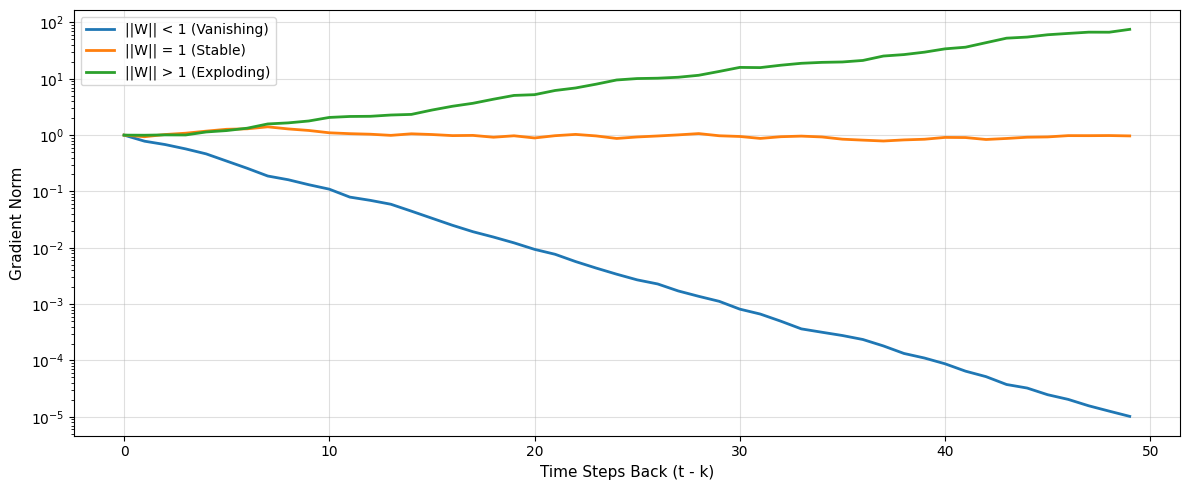

In [13]:
# Simulate vanishing gradient effect for illustration
time_steps = 50
np.random.seed(42)

# Different weight scales (Khapra's analysis)
scales = {
    "||W|| < 1 (Vanishing)": 0.8,
    "||W|| = 1 (Stable)"   : 1.0,
    "||W|| > 1 (Exploding)": 1.1
}

plt.figure(figsize=(12, 5))

for label, scale in scales.items():
    grad_norm = [1.0]
    for _ in range(time_steps - 1):
        # Simulate: gradient norm shrinks/grows by factor 'scale' each step
        next_norm = grad_norm[-1] * scale * (0.9 + 0.2 * np.random.rand())
        grad_norm.append(next_norm)

    plt.plot(grad_norm, label=label, linewidth=2)


plt.xlabel("Time Steps Back (t - k)", fontsize=11)
plt.ylabel("Gradient Norm", fontsize=11)
plt.yscale("log")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("vanishing_gradients.png", dpi=150)
plt.show()



| Concept | Khapra Notation | This Code |
|---------|----------------|-----------|
| Input | $x_t$ | `x_t` (char index) |
| Hidden state | $s_t = \tanh(Wx_t + Us_{t-1} + b_s)$ | `SimpleRNN` layer |
| Output | $\hat{y}_t = \text{softmax}(Vs_t + b_y)$ | `Dense` + `softmax` |
| Loss | $\mathcal{L} = -\sum_t \log \hat{y}_t^{(x_{t+1})}$ | `SparseCategoricalCrossentropy` |
| Training | BPTT — $\frac{\partial \mathcal{L}}{\partial U}$ | `model.fit()` |
| Sampling | $x_{t+1} \sim \text{Categorical}(\text{softmax}(\hat{y}_t/\tau))$ | `generate_text()` |

---

### 📚 References
- **Prof. Mitesh M. Khapra**, CS7015 Deep Learning, IIT Madras — [NPTEL Course](https://nptel.ac.in/courses/106106184)
- Lecture 9: Introduction to RNNs
- Lecture 10: BPTT — Backpropagation Through Time
- Lecture 11: Vanishing & Exploding Gradients
- Karpathy, A. (2015). *The Unreasonable Effectiveness of Recurrent Neural Networks*